In [20]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

np.random.seed(42)

In [21]:
products = ["Laptop", "Mobile", "Tablet", "TV"]
cities = ["Bangalore", "Chennai", "Hyderabad", "Kochi"]
months = ["Jan", "Feb", "Mar", "Apr", "May"]

payment_modes = ["UPI", "Card", "Cash"]
customer_types = ["New", "Returning"]

records = []
record_id = 1

for city in cities:
    for product in products:
        for month in months:

            sales = np.random.randint(80, 201)

            records.append({
                "RecordID": record_id,
                "Product": product,
                "City": city,
                "Month": month,
                "PaymentMode": np.random.choice(payment_modes),
                "CustomerType": np.random.choice(customer_types),
                "Sales": sales
            })

            record_id += 1

df = pd.DataFrame(records)

print(df.head())

   RecordID Product       City Month PaymentMode CustomerType  Sales
0         1  Laptop  Bangalore   Jan         UPI          New    182
1         2  Laptop  Bangalore   Feb         UPI          New    186
2         3  Laptop  Bangalore   Mar        Card          New    182
3         4  Laptop  Bangalore   Apr        Cash          New    166
4         5  Laptop  Bangalore   May         UPI    Returning    167


In [22]:
df["SalesLevel"] = pd.cut(
    df["Sales"],
    bins=[0,110,160,250],
    labels=["Low","Medium","High"]
)

transactions = []

for i in range(len(df)):

    transaction = [
        "Product=" + df.loc[i,"Product"],
        "City=" + df.loc[i,"City"],
        "Month=" + df.loc[i,"Month"],
        "Payment=" + df.loc[i,"PaymentMode"],
        "Customer=" + df.loc[i,"CustomerType"],
        "Sales=" + str(df.loc[i,"SalesLevel"])
    ]

    transactions.append(transaction)

encoder = TransactionEncoder()

onehot = encoder.fit(transactions).transform(transactions)

onehot_df = pd.DataFrame(onehot, columns=encoder.columns_)

print(onehot_df.head())

   City=Bangalore  City=Chennai  City=Hyderabad  City=Kochi  Customer=New  \
0            True         False           False       False          True   
1            True         False           False       False          True   
2            True         False           False       False          True   
3            True         False           False       False          True   
4            True         False           False       False         False   

   Customer=Returning  Month=Apr  Month=Feb  Month=Jan  Month=Mar  ...  \
0               False      False      False       True      False  ...   
1               False      False       True      False      False  ...   
2               False      False      False      False       True  ...   
3               False       True      False      False      False  ...   
4                True      False      False      False      False  ...   

   Payment=Card  Payment=Cash  Payment=UPI  Product=Laptop  Product=Mobile  \
0         Fals

In [23]:
frequent_itemsets = apriori(
    onehot_df,
    min_support=0.20,
    use_colnames=True
)

print(frequent_itemsets)

    support                      itemsets
0    0.2500              (City=Bangalore)
1    0.2500                (City=Chennai)
2    0.2500              (City=Hyderabad)
3    0.2500                  (City=Kochi)
4    0.5375                (Customer=New)
5    0.4625          (Customer=Returning)
6    0.2000                   (Month=Apr)
7    0.2000                   (Month=Feb)
8    0.2000                   (Month=Jan)
9    0.2000                   (Month=Mar)
10   0.2000                   (Month=May)
11   0.3125                (Payment=Card)
12   0.3625                (Payment=Cash)
13   0.3250                 (Payment=UPI)
14   0.2500              (Product=Laptop)
15   0.2500              (Product=Mobile)
16   0.2500                  (Product=TV)
17   0.2500              (Product=Tablet)
18   0.3000                  (Sales=High)
19   0.2875                   (Sales=Low)
20   0.4125                (Sales=Medium)
21   0.2250  (Customer=New, Payment=Cash)
22   0.2250  (Customer=New, Sales=

In [24]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

print(rules[
    ["antecedents","consequents","support","confidence","lift"]
])

      antecedents     consequents  support  confidence      lift
0  (Payment=Cash)  (Customer=New)    0.225     0.62069  1.154771


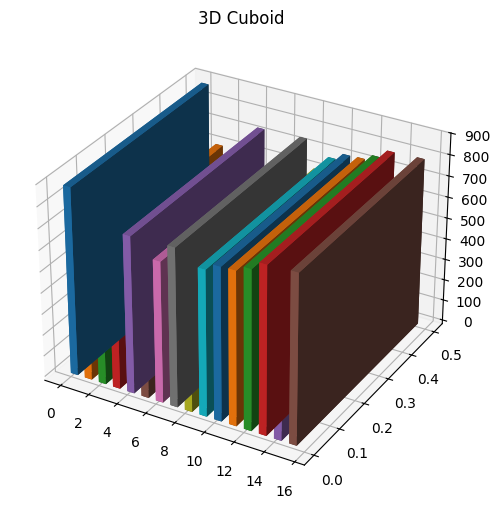

In [25]:
cube = df.groupby(["Product","City"])["Sales"].sum().reset_index()

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

for i in range(len(cube)):

    ax.bar3d(
        i,
        0,
        0,
        0.5,
        0.5,
        cube.loc[i,"Sales"]
    )

ax.set_title("3D Cuboid")

plt.show()

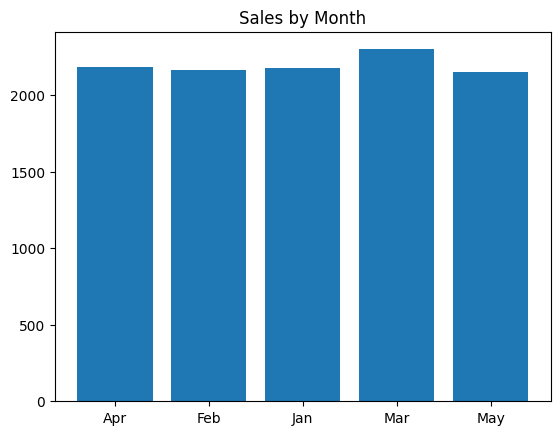

In [26]:
rollup = df.groupby("Month")["Sales"].sum()

plt.bar(
    rollup.index,
    rollup.values
)

plt.title("Sales by Month")
plt.show()

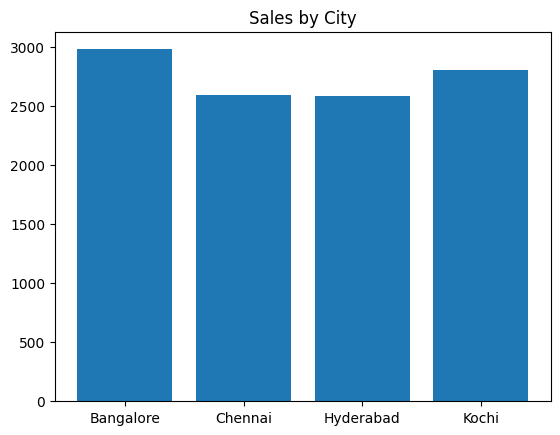

In [27]:
drill = df.groupby("City")["Sales"].sum()

plt.bar(
    drill.index,
    drill.values
)

plt.title("Sales by City")

plt.show()

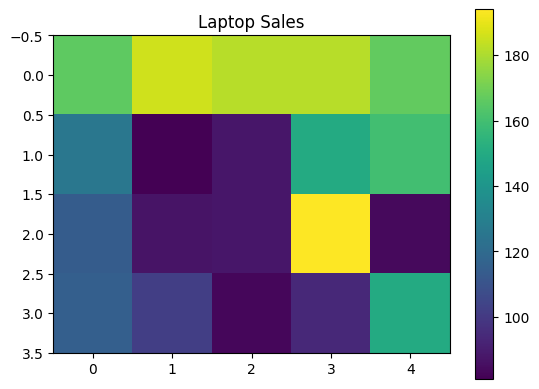

In [28]:
laptop = df[df["Product"]=="Laptop"]

table = laptop.pivot_table(
    index="City",
    columns="Month",
    values="Sales",
    aggfunc="sum",
    fill_value=0
)

plt.imshow(table)

plt.colorbar()

plt.title("Laptop Sales")

plt.show()

In [29]:
dice = df[
    (df["Product"].isin(["Laptop","Mobile"])) &
    (df["City"].isin(["Bangalore","Chennai"]))
]

print(dice)


    RecordID Product       City Month PaymentMode CustomerType  Sales  \
0          1  Laptop  Bangalore   Jan         UPI          New    182   
1          2  Laptop  Bangalore   Feb         UPI          New    186   
2          3  Laptop  Bangalore   Mar        Card          New    182   
3          4  Laptop  Bangalore   Apr        Cash          New    166   
4          5  Laptop  Bangalore   May         UPI    Returning    167   
5          6  Mobile  Bangalore   Jan        Cash    Returning    183   
6          7  Mobile  Bangalore   Feb        Card    Returning    132   
7          8  Mobile  Bangalore   Mar        Card    Returning    187   
8          9  Mobile  Bangalore   Apr         UPI          New     81   
9         10  Mobile  Bangalore   May        Card    Returning    155   
20        21  Laptop    Chennai   Jan        Card          New     88   
21        22  Laptop    Chennai   Feb        Cash    Returning     81   
22        23  Laptop    Chennai   Mar         UPI  

In [30]:
pivot = df.pivot_table(
    index="City",
    columns="Product",
    values="Sales",
    aggfunc="sum",
    fill_value=0
)

print(pivot)

Product    Laptop  Mobile   TV  Tablet
City                                  
Bangalore     883     738  613     749
Chennai       605     516  686     789
Hyderabad     567     662  719     638
Kochi         544     746  722     794


**INTERPRETATION**

In this program, I created a sample sales dataset with details like products, cities, months, payment methods, customer types, and sales values. I then used the Apriori algorithm to find common purchasing patterns and generate association rules. Next, I performed different OLAP operations such as roll-up, drill-down, slice, dice, and pivot table to analyze the sales data from different views. Finally, I displayed the results using graphs and a 3D chart, which made it easier to understand sales trends and compare the data.